# Statistical Significance Testing
---

## Introduction:

This document aims to answer the project's central question: "Which marketing campaign was most effective in increasing sales?" We won't simply look at the apparent numbers; we'll use advanced statistical tests to ensure our decisions are based on sound scientific principles.

**Objectives:**

- Statistical Comparison: Using ANOVA to confirm the existence of real differences between the three campaigns.

- Identifying the Winner: Conducting Tukey's HSD pairwise comparison test to determine which campaign outperformed the others.

- Providing Recommendations: Formulating a final recommendation based on the statistical results to support company decision-making.

*Technical Note: This document relies on processed data saved in the `data/processed/` folder to ensure the accuracy of the statistical results.*

In [2]:
!pip install statsmodels 

Defaulting to user installation because normal site-packages is not writeable


In [3]:
#impor Required libraries
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/home/mona/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
clean_data = pd.read_csv('/home/mona/Downloads/SAD/AAI/student/Data Science/project 1: Fast food marketing/data/processed/marketing_cleaned.csv')


clean_data.head()

,marketid,marketsize,locationid,ageofstore,promotion,week,salesinthousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [5]:
# Comparing average sales across the three campaigns
promotion_performance = clean_data.groupby('promotion')['salesinthousands'].mean().sort_values(ascending=False)
print(promotion_performance)

promotion
1    54.037532
3    52.905909
2    46.668865
Name: salesinthousands, dtype: float64


*Remember: the mean values ​​differed from the mean values ​​before and after the data cleaning process.*

promotion

1    58.099012

2    47.329415

3    55.364468

---

Analyzing market distribution (Where did it occur?)

Instead of the overall average, we will divide the average by market size. This will reveal whether the campaign was "broad" or "specific."

In [8]:
# Comparing campaign performance based on market size
market_analysis = clean_data.groupby(['promotion', 'marketsize'])['salesinthousands'].mean().unstack()
print(market_analysis)

marketsize      Large     Medium      Small
promotion                                  
1           66.893684  47.672604  60.162500
2           58.957705  39.114352  50.810625
3           72.464167  45.468879  59.514167


___

Time analysis (When did it happen?)

Since the experiment lasted four weeks, we need to ensure that the sales weren't a fluke in a single week.

Objective: Were campaign sales consistent throughout the month?

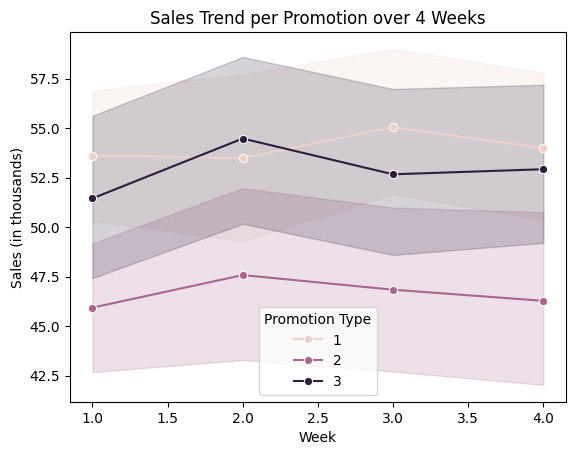

In [9]:
sns.lineplot(data=clean_data, x='week', y='salesinthousands', hue='promotion', marker='o')

plt.title('Sales Trend per Promotion over 4 Weeks')
plt.xlabel('Week')
plt.ylabel('Sales (in thousands)')
plt.legend(title='Promotion Type')


## One-Way ANOVA.

In [10]:
from scipy import stats

# 1. Divide the data into three groups based on the campaign type.
group1 = clean_data[clean_data['promotion'] == 1]['salesinthousands']
group2 = clean_data[clean_data['promotion'] == 2]['salesinthousands']
group3 = clean_data[clean_data['promotion'] == 3]['salesinthousands']

# 2. Make test ANOVA
f_stat, p_value = stats.f_oneway(group1, group2, group3)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

F-Statistic: 14.7789
P-Value: 0.0000


**F-statistic (14.77):** This number represents the degree of dispersion between the means relative to the dispersion within each group. The larger this number, **the greater the confidence that a significant difference exists.**

**Since the p-value is 0.0000** (much smaller than the significance level of 0.05), this statistically means that the results are highly significant.

If P-Value > 0.05:

*Decision: We **fail** to reject the null hypothesis.*

Meaning: The differences between the campaigns may be due to "noise" or randomness in the data, and there is not enough statistical evidence to conclude that one is better than the other.

## Post-hoc

In [11]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Conduct a paired comparison test to determine the difference between each campaign.
tukey = pairwise_tukeyhsd(endog=clean_data['salesinthousands'], 
                          groups=clean_data['promotion'], 
                          alpha=0.05)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -7.3687    0.0 -10.876 -3.8614   True
     1      3  -1.1316 0.7339 -4.6794  2.4162  False
     2      3    6.237 0.0001  2.8515  9.6226   True
----------------------------------------------------


---

**Campaign #2** is definitely the weakest, and the difference between it and the others is real, not a coincidence (Reject = True).

**Campaigns #1 and #3** are the best, and the difference between them is so small that it's statistically a tie (Reject = False).

---
## final decision:
we can choose either one (1 or 3) based on cost or ease of implementation, as they achieved the same statistical success.

## Future Recommendations & Proposed Studies

Since statistical results showed no significant difference between Promotion 1 and 3, we recommend the following to reach a definitive decision:

- **Deep Dive into Operational Metrics:**

    Staffing Levels: Investigate if employee count influenced campaign execution and customer experience.

    Operational Efficiency: Monitor order wait times and inventory levels to ensure sales growth didn't compromise service quality.

- **Re-evaluating Outliers (The Success Recipe):**

    While outliers were removed for statistical accuracy, we observed exceptional performance in younger stores.

    Recommendation: Conduct a Qualitative Study on these high-performers to identify if their success stems from location, management style, or specific customer demographics.

- **Store Age Optimization:**

    Research to identify the "Golden Age" of a store—the point at which it responds most effectively to marketing prompts—to optimize future budget allocation.

- **ROI Analysis (Cost vs. Return):**

    Since Promotions 1 and 3 are statistically tied in sales performance, the tie-breaker should be Cost-Effectiveness.

    Recommendation: Select the promotion with the lower operational cost or the higher net profit margin after marketing expenses.